# Library Import

In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import norm

np.random.seed(42)

# DataFrame Creation

In [142]:
# Tabela de obras
obras = pd.DataFrame({
    "obra_id": [1, 2, 3, 4, 5],
    "nome_obra": ["Torre A", "Torre B", "Torre C", "Torre D", "Torre E"],
    "pavimentos": [5, 6, 7, 4, 8],
    "status": ["ativa"] * 5,
    "fase_inicial": ["Acelerada"] * 5
})
# Timeline
datas = pd.date_range(start="2025-01-01", periods=90)

# Baseline
fator = 8 # m³ de agua por pavimento por dia
obras["consumo_base_m3"] = obras["pavimentos"] * fator

obras

,obra_id,nome_obra,pavimentos,status,fase_inicial,consumo_base_m3
0,1,Torre A,5,ativa,Acelerada,40
1,2,Torre B,6,ativa,Acelerada,48
2,3,Torre C,7,ativa,Acelerada,56
3,4,Torre D,4,ativa,Acelerada,32
4,5,Torre E,8,ativa,Acelerada,64


# Water Consumption Model

In [155]:
def nome_fase(dia):
    if dia <= 30:
        return "Acelerada"
    elif dia <= 60:
        return "Intermediária"
    else:
        return "Redução"

def fator_fase(fase):
    fatores = {
        "Acelerada": 1.2,
        "Intermediária": 1.0,
        "Redução": 0.85
    }
    return fatores[fase]

registros = []

for _, obra in obras.iterrows():
    
    base = obra["consumo_base_m3"]
    torre = obra["nome_obra"]
    ruido_anterior = 1
    
    for i, data in enumerate(datas, start=1):
        
        n_fase = nome_fase(i)
        fator = fator_fase(n_fase)

        # Noise creation
        erro = np.random.normal(0, 0.03)
        ruido = 0.6 * (ruido_anterior - 1) + erro + 1
        consumo_dia = base * fator * ruido

        # Leak_1 — Torre D
        if torre == 'Torre D' and 10 <= i <= 35:
            consumo_dia *= 1 + 0.01 * (i - 10)
        
        # Leak_2 — Torre E
        if torre == 'Torre E' and i >= 40:
            t = i - 40
            if t < 10:
                consumo_dia *= 1 + 0.002 * t
            else:
                consumo_dia *= 1 + 0.08 / (1 + np.exp(-0.4 * (t - 10)))
                
        ruido_anterior = ruido
        
        registros.append({
            "dia_obra": i,
            "data": data,
            "obra_id": obra["obra_id"],
            "nome_obra": obra["nome_obra"],
            "fase": n_fase,
            "consumo_m3": consumo_dia
        })

consumo_agua = pd.DataFrame(registros)

consumo_agua.tail()

,dia_obra,data,obra_id,nome_obra,fase,consumo_m3
445,86,2025-03-27,5,Torre E,Redução,62.882421
446,87,2025-03-28,5,Torre E,Redução,60.935697
447,88,2025-03-29,5,Torre E,Redução,60.320810
448,89,2025-03-30,5,Torre E,Redução,61.819830
449,90,2025-03-31,5,Torre E,Redução,59.152800


# Auxiliary Functions

In [156]:
def filtrar_obra(df, nome):
    if nome not in df["nome_obra"].unique():
        raise ValueError("Obra não encontrada")
    return df[df["nome_obra"] == nome].copy()

def filtrar_fase(df, fase):
    if fase not in df["fase"].unique():
        raise ValueError("Fase não encontrada.")
    return df[df["fase"] == fase].copy()

# Exploratory Data Analysis (EDA)

## DF Overview

In [157]:
consumo_agua.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dia_obra    450 non-null    int64         
 1   data        450 non-null    datetime64[ns]
 2   obra_id     450 non-null    int64         
 3   nome_obra   450 non-null    object        
 4   fase        450 non-null    object        
 5   consumo_m3  450 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 21.2+ KB


In [158]:
consumo_agua.describe()

,dia_obra,data,obra_id,consumo_m3
count,450.000000,450,450.000000,450.000000
mean,45.500000,2025-02-14 11:59:59.999999744,3.000000,49.588190
min,1.000000,2025-01-01 00:00:00,1.000000,25.781355
25%,23.000000,2025-01-23 00:00:00,2.000000,38.812293
50%,45.500000,2025-02-14 12:00:00,3.000000,47.899801
75%,68.000000,2025-03-09 00:00:00,4.000000,60.424202
max,90.000000,2025-03-31 00:00:00,5.000000,84.323022
std,26.008072,NaN,1.415788,13.975328


## Temporal Series

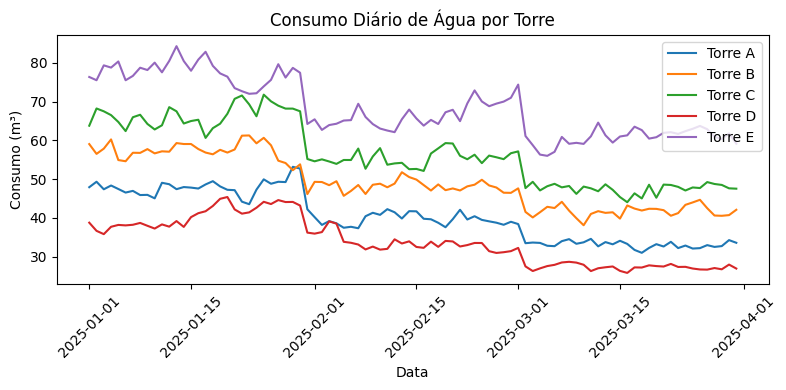

In [159]:
plt.figure(figsize=(8,4))

for nome_obra, df_obra in consumo_agua.groupby("nome_obra"):
    plt.plot(df_obra["data"], df_obra["consumo_m3"], label=nome_obra)

plt.title("Consumo Diário de Água por Torre")
plt.xlabel("Data")
plt.ylabel("Consumo (m³)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Torre D apresenta comportamento anômalo crescente após 1 etapa.

## Tower Comparison

### BoxPlot

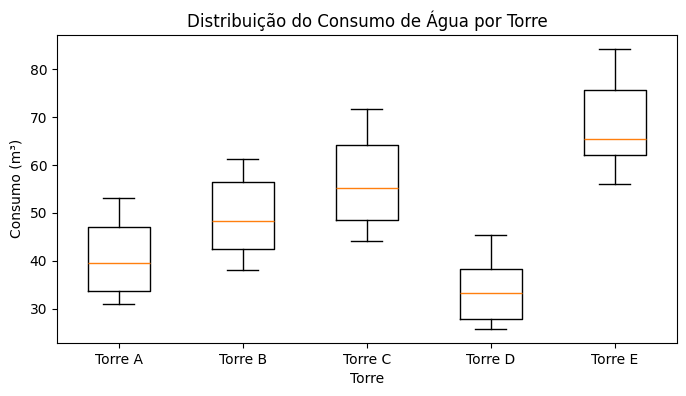

In [160]:
dados_boxplot = [
    df["consumo_m3"].values
    for _, df in consumo_agua.groupby("nome_obra")
]

labels = consumo_agua["nome_obra"].unique()

plt.figure(figsize=(8,4))
plt.boxplot(dados_boxplot, labels=labels)
plt.title("Distribuição do Consumo de Água por Torre")
plt.xlabel("Torre")
plt.ylabel("Consumo (m³)")
plt.show()

Torre D<br>

compressão de variância

deslocamento do nível médio

comportamento fora do esperado dado o tamanho<br>

Torre E<br>

assimetria positiva (right-skew)<br>

eventos extremos superiores<br>

variabilidade tardia<br>

### Average Consumption by Tower

In [167]:
media = (
    consumo_agua.groupby("nome_obra")["consumo_m3"]
    .mean()
    .sort_values()
    .to_frame("Average Consumption (m³)")
)

display(media)

,Average Consumption (m³)
nome_obra,
Torre D,33.788506
Torre A,40.236599
Torre B,49.104691
Torre C,56.475983
Torre E,68.335173


Apesar de possuir mais pavimentos que A, B e C, torre D apresenta consumo médio inferior.

### Standard Deviation by Tower

In [168]:
std = (
    consumo_agua.groupby("nome_obra")["consumo_m3"]
    .std()
    .sort_values()
    .to_frame("Standard Deviation (m³)")
)

display(std)

,Standard Deviation (m³)
nome_obra,
Torre D,5.832819
Torre A,6.290589
Torre B,6.683091
Torre E,7.550915
Torre C,8.097813


O menor desvio padrão da Torre D, apesar da menor quantidade de pavimentos, sugere comportamento atípico do consumo ao longo do tempo.<br>
A Torre E apresentar desvio padrão inferior à Torre C levanta suspeitas sobre seu consumo geral.

## Tower D Anomaly Evaluation

### Temporal Series

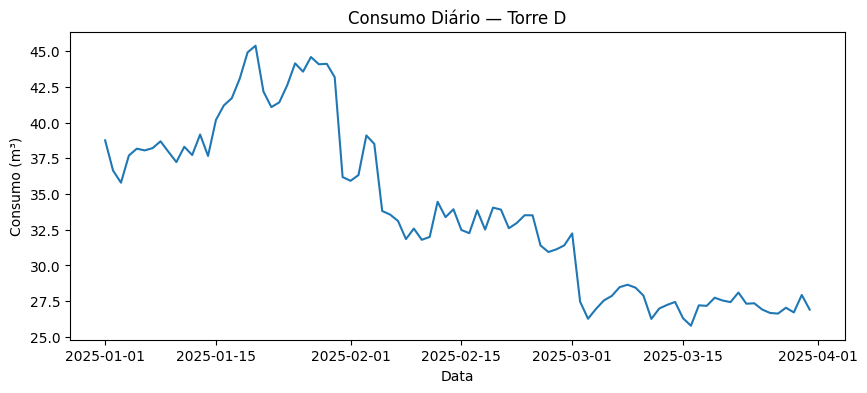

In [169]:
torre_d = filtrar_obra(consumo_agua, "Torre D")

plt.figure(figsize=(10,4))
plt.plot(torre_d["data"], torre_d["consumo_m3"])
plt.title("Consumo Diário — Torre D")
plt.xlabel("Data")
plt.ylabel("Consumo (m³)")
plt.show()

### Tower D vs Others Comparison

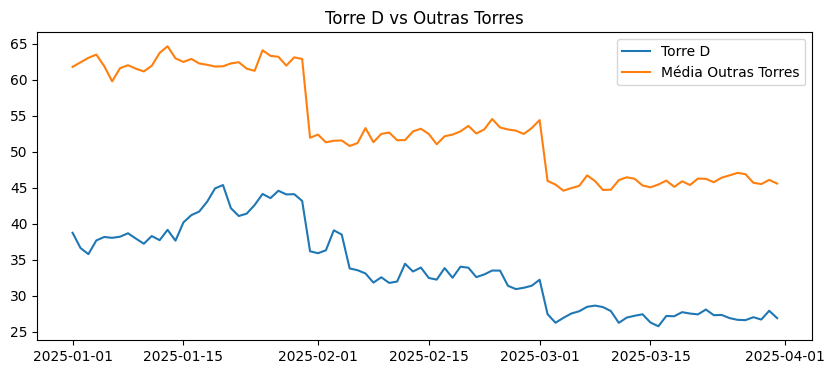

In [170]:
media_por_data = consumo_agua.groupby(["data","nome_obra"])["consumo_m3"].mean().unstack()

plt.figure(figsize=(10,4))
plt.plot(media_por_data.index, media_por_data["Torre D"], label="Torre D")

outras = media_por_data.drop(columns="Torre D").mean(axis=1)
plt.plot(media_por_data.index, outras, label="Média Outras Torres")

plt.legend()
plt.title("Torre D vs Outras Torres")
plt.show()

Observa-se que o perfil de consumo na Torre D nas etapas iniciais diverge daquele observado na média das demais.

## Linear Regression

In [171]:
torre_d = torre_d.reset_index(drop=True)

X = pd.Series(range(len(torre_d["consumo_m3"])))
Y = torre_d["consumo_m3"]

# Adicionando o intercepto
X = sm.add_constant(X)

# Criando e ajustando o modelo
model_rlint = sm.OLS(Y, X)
results_rlint = model_rlint.fit()

# Exibindo o sumário do modelo
print(results_rlint.summary())

                            OLS Regression Results                            
Dep. Variable:             consumo_m3   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     256.9
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           7.78e-28
Time:                        15:17:53   Log-Likelihood:                -224.45
No. Observations:                  90   AIC:                             452.9
Df Residuals:                      88   BIC:                             457.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         42.3632      0.620     68.383      0.0

Embora a regressão linear global apresente bom ajuste estatístico aparente, ela é insuficiente para caracterizar o comportamento anômalo do consumo de água na Torre D.<br>A forte autocorrelação dos resíduos indica que o processo possui dependência temporal significativa, tornando inadequada a utilização de modelos lineares simples para detecção precoce de vazamentos.<br>Esses resultados sugerem que existem abordagens mais apropriadas

## Phase Analisys

In [172]:
torre_d = filtrar_obra(consumo_agua, "Torre D")

fases = ["Acelerada", "Intermediária", "Redução"]

for fase in fases:
    
    df_fase = filtrar_fase(torre_d, fase).reset_index(drop=True)
    
    X = pd.Series(range(len(df_fase)), name="tempo")
    X = sm.add_constant(X)
    Y = df_fase["consumo_m3"]
    
    results = sm.OLS(Y, X).fit()
    
    coef = results.params.iloc[1]
    pval = results.pvalues.iloc[1]
    
    print(f"Fase: {fase}")
    print(f"Coeficiente tempo: {coef:.4f}")
    print(f"P-value: {pval:.4f}")
    print("-"*40)

Fase: Acelerada
Coeficiente tempo: 0.2852
P-value: 0.0000
----------------------------------------
Fase: Intermediária
Coeficiente tempo: -0.1494
P-value: 0.0001
----------------------------------------
Fase: Redução
Coeficiente tempo: -0.0157
P-value: 0.2896
----------------------------------------


### Hypothesis Test — Phase Analysis (Tower D)

Para cada fase da construção, foi ajustado um modelo de regressão linear simples para avaliar se o consumo de água apresenta tendência positiva ao longo do tempo.

#### Hipóteses

**H₀:** Não há crescimento positivo do consumo ao longo do tempo na fase  
β₁ = 0  

**H₁:** Há crescimento positivo do consumo ao longo do tempo na fase  
β₁ > 0  

---

#### Fase Acelerada

Coeficiente: +0.2852  
p-value: < 0.001  

O coeficiente é positivo e estatisticamente significativo.  
**Rejeita-se H₀.** Há evidência de crescimento do consumo ao longo do tempo.

---

#### Fase Intermediária

Coeficiente: −0.1494  
p-value: < 0.001  

Embora significativo, o coeficiente é negativo.  
Não há evidência de crescimento positivo.  
**Não se rejeita H₀.**

---

#### Fase de Redução

Coeficiente: −0.0157  
p-value: 0.2896  

O coeficiente não é estatisticamente significativo.  
**Não se rejeita H₀.**

---

#### Conclusão

Evidência de crescimento positivo do consumo foi observada apenas na fase Acelerada.  
As fases posteriores não apresentam tendência positiva significativa.

# Business Impact

## Baseline / Benchmark

In [175]:
# Filtrar fases
fases_vazamento = ["Acelerada"]
df_vaz = consumo_agua[consumo_agua["fase"].isin(fases_vazamento)].copy()

# Separar Torre D
df_d = df_vaz[df_vaz["nome_obra"] == "Torre D"].copy()
df_outras = df_vaz[df_vaz["nome_obra"] != "Torre D"].copy()

# Calculo de pavimentos
pav_D = obras.loc[obras["nome_obra"] == "Torre D", "pavimentos"].values[0]
pav_outras = obras.loc[obras["nome_obra"] != "Torre D", "pavimentos"].sum()

# Consumo total outras
consumo_outras_dia = (
    df_outras
    .groupby("data")["consumo_m3"]
    .sum()
    .reset_index()
)

# Baseline Torre D
consumo_outras_dia["baseline_D"] = (
    consumo_outras_dia["consumo_m3"] / pav_outras
) * pav_D

# Associar ao real D
df_d = df_d[["data", "consumo_m3"]].rename(
    columns={"consumo_m3": "consumo_real_D"}
)

df_compare = df_d.merge(consumo_outras_dia[["data", "baseline_D"]],
                        on="data")

## Overconsumption Calculation

In [176]:
df_compare["excesso"] = (
    df_compare["consumo_real_D"] - df_compare["baseline_D"]
)

excesso_total = df_compare["excesso"].sum()

percentual = (
    excesso_total / df_compare["baseline_D"].sum()
) * 100

print(f"Excesso acumulado: {excesso_total:.2f} m³")
print(f"Percentual acima do esperado: {percentual:.2f}%")

Excesso acumulado: 66.00 m³
Percentual acima do esperado: 5.73%


## Conclusion

### Excesso de Consumo — Fase Acelerada (Torre D)

Para isolar o impacto da anomalia, a comparação foi restrita à fase Acelerada, período no qual ocorre o comportamento anormal de consumo.

Excesso acumulado de consumo: **66,00 m³**  
Aumento relativo em relação ao baseline esperado: **5,73%**

---

#### Interpretação

Embora moderado em termos absolutos, esse excesso ocorreu durante a fase mais intensiva em uso de recursos da construção e foi normalizado pelo número de pavimentos, permitindo uma comparação justa entre torres de diferentes portes.

Como a estimativa é ajustada por escala estrutural, o desvio observado representa uma variação operacional real, e não apenas efeito do tamanho da obra.

Desvios persistentes dessa magnitude durante a fase de maior consumo podem gerar impactos acumulados significativos ao longo do projeto caso não sejam identificados e corrigidos.

---

#### Relevância Operacional

Em ambientes reais de construção, excesso de consumo hídrico nas fases iniciais pode indicar:

- Vazamentos ocultos ou ineficiências operacionais  
- Aumento de custos com utilidades e abastecimento  
- Risco de agravamento ao longo do tempo  
- Impacto no planejamento de recursos e metas de sustentabilidade  

Assim, mesmo desvios percentuais aparentemente modestos merecem investigação quando ocorrem de forma sistemática em estágios críticos da obra.

Em resumo, a análise indica uma ineficiência mensurável concentrada no período de maior consumo da obra, compatível com um evento anômalo persistente.

## Investigação Inicial — Variabilidade do Consumo

A análise do desvio padrão do consumo diário por torre revelou diferenças relevantes na variabilidade das séries temporais.

| Torre | Desvio padrão (m³) |
|-------|--------------------|
| Torre D | 5,83 |
| Torre A | 6,29 |
| Torre B | 6,68 |
| Torre E | 7,55 |
| Torre C | 8,10 |

---

### Interpretação

A Torre D apresenta a menor variabilidade, apesar de possuir menor escala estrutural. Esse comportamento é consistente com a presença de um fator anômalo progressivo, que pode reduzir oscilações relativas ao introduzir um aumento sistemático no consumo.

Já a Torre E apresenta variabilidade inferior à Torre C, mesmo possuindo maior número de pavimentos. Essa estabilidade relativa pode indicar um padrão de consumo distinto do esperado, sugerindo a possibilidade de comportamento anômalo mais sutil.

---

### Motivação para Análise Bayesiana

Diferenças de variabilidade isoladamente não constituem evidência conclusiva de anomalia, mas podem servir como sinal preliminar de mudança de regime operacional.

Dessa forma, a análise probabilística Bayesiana será utilizada para avaliar a plausibilidade de que o consumo observado na Torre E esteja associado a um comportamento anormal, considerando a incerteza inerente aos dados.

# Bayesian Inference

## Inferência Bayesiana — Probabilidade de Vazamento em Torre Similar

Considerando a ocorrência confirmada de vazamento na Torre D, deseja-se estimar a probabilidade de que outra torre apresente comportamento anômalo semelhante, dado o consumo observado.

A presença de um evento conhecido em um ativo similar pode aumentar a probabilidade a priori de falha em outros ativos sujeitos às mesmas condições operacionais.

Assim, busca-se estimar:

P(vazamento na Torre E | dados observados na Torre E, vazamento na Torre D)

Essa abordagem permite incorporar conhecimento prévio sobre o sistema, combinado com evidências empíricas, fornecendo uma estimativa probabilística mais realista do risco de anomalia.

Importante ressaltar que não se assume causalidade direta entre as torres, mas sim compartilhamento de fatores estruturais e operacionais que podem influenciar o comportamento de consumo.

### Definição do Prior — Probabilidade Base de Vazamento

Para estimar a probabilidade inicial de vazamento em outras torres, utilizou-se a ocorrência observada no conjunto analisado.

O empreendimento é composto por 5 torres com um total de 30 pavimentos:

- Torre A: 5 pavimentos  
- Torre B: 6 pavimentos  
- Torre C: 7 pavimentos  
- Torre D: 4 pavimentos  
- Torre E: 8 pavimentos  

Um vazamento foi confirmado na Torre D.

---

### Prior Empírico Ponderado por Escala Estrutural

Em vez de assumir risco igual para todas as torres, utilizou-se uma estimativa baseada na proporção de pavimentos afetados pelo evento observado.

O empreendimento possui 30 pavimentos distribuídos entre cinco torres. O vazamento confirmado ocorreu em uma torre com 4 pavimentos.

Assim, a taxa empírica de ocorrência por unidade estrutural é:

P(vazamento por pavimento) = 4 / 30 ≈ 0,133

---

### Interpretação

Essa estimativa pode ser interpretada como uma taxa base de risco associada à infraestrutura hídrica instalada, assumindo que a probabilidade de falha aumenta com a complexidade estrutural.

Torres com maior número de pavimentos apresentam maior exposição potencial, embora a probabilidade final de vazamento dependa também de fatores operacionais e construtivos.

---

### Observação

Como apenas um evento foi observado, essa taxa representa um prior empírico preliminar e deve ser atualizada à medida que novas evidências forem incorporadas ao modelo.

## Set up DF excesso

In [193]:
# consumo por pavimento por dia
df_vaz["consumo_por_pav"] = (
    df_vaz["consumo_m3"] /
    df_vaz["nome_obra"].map(
        obras.set_index("nome_obra")["pavimentos"]
    )
)

# baseline normal = média das torres sem vazamento
normais = df_vaz[df_vaz["nome_obra"] != "Torre D"]

baseline_norm = (
    normais.groupby("data")["consumo_por_pav"]
    .mean()
    .reset_index(name="baseline_por_pav")
)

# Torre D normalizada
df_d_norm = df_vaz[df_vaz["nome_obra"] == "Torre D"][
    ["data", "consumo_por_pav"]
]

df_excesso_D = df_d_norm.merge(
    baseline_norm,
    on="data"
)

df_excesso_D["excesso"] = (
    df_excesso_D["consumo_por_pav"] -
    df_excesso_D["baseline_por_pav"]
)

excesso_D = df_excesso_D["excesso"].values

# Torre E normalizada
df_e_norm = df_vaz[df_vaz["nome_obra"] == "Torre E"][
    ["data", "consumo_por_pav"]
]

df_excesso_E = df_e_norm.merge(
    baseline_norm,
    on="data"
)

df_excesso_E["excesso"] = (
    df_excesso_E["consumo_por_pav"] -
    df_excesso_E["baseline_por_pav"]
)

excesso_E = df_excesso_E["excesso"].values

# Demais torres - sem suspeitas
excesso_normais = []

for torre in ["Torre A", "Torre B", "Torre C"]:
    
    df_t = df_vaz[df_vaz["nome_obra"] == torre][
        ["data", "consumo_por_pav"]
    ]
    
    df_t = df_t.merge(baseline_norm, on="data")
    
    excesso = (
        df_t["consumo_por_pav"] -
        df_t["baseline_por_pav"]
    )
    
    excesso_normais.extend(excesso.values)

excesso_normais = np.array(excesso_normais)

## Bayes Application

In [231]:
# parâmetros estimados
mu_leak = excesso_D.mean()
sigma_leak = excesso_D.std()

mu_norm = excesso_normais.mean()
sigma_norm = excesso_normais.std()

# log-likelihoods (dados de E)
ll_leak = norm.logpdf(excesso_E, mu_leak, sigma_leak).sum()
ll_norm = norm.logpdf(excesso_E, mu_norm, sigma_norm).sum()

# log-priors
log_prior_leak = np.log(prior_leak)
log_prior_norm = np.log(prior_norm)

# log posterior não normalizado
log_p_leak = ll_leak + log_prior_leak
log_p_norm = ll_norm + log_prior_norm

# 🔥 LOG-SUM-EXP trick
max_log = max(log_p_leak, log_p_norm)

window = 1
posterior = prior_leak
posteriores = []

for i in range(len(excesso_E)):

    x = excesso_E[max(0, i-window+1):i+1].mean()

    p_x_leak = norm.pdf(x, mu_leak, sigma_leak)
    p_x_norm = norm.pdf(x, mu_norm, sigma_norm)

    posterior = (
        p_x_leak * posterior /
        (p_x_leak * posterior +
         p_x_norm * (1 - posterior))
    )
    posterior = np.clip(posterior, 1e-6, 1 - 1e-6)
    posteriores.append(posterior)

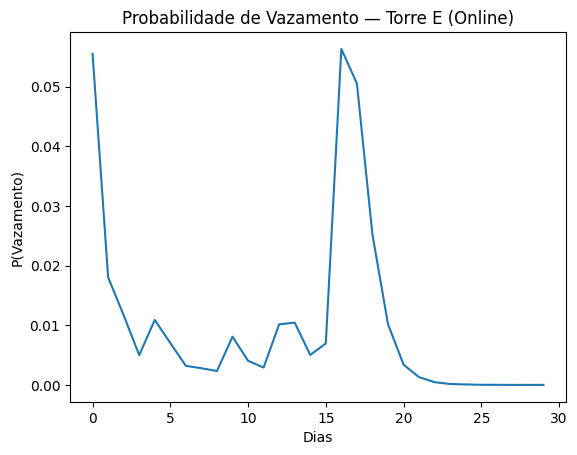

In [232]:
plt.plot(posteriores)
plt.title("Probabilidade de Vazamento — Torre E (Online)")
plt.xlabel("Dias")
plt.ylabel("P(Vazamento)")
plt.show()

## Early Detection Tool

In [247]:
# Calculo do gradiente
grad = np.gradient(posteriores)

# Gradiente suavizado
p_smooth = pd.Series(posteriores).rolling(
    window=3, center=True, min_periods=1
).mean()

grad = np.gradient(p_smooth)

# Baseline (período normal)
baseline = 10

mu = grad[:baseline].mean()
sigma = grad[:baseline].std()

z = (grad - mu) / sigma

threshold = 2.5

detected_day = next(
    (i for i, value in enumerate(z) if value >= threshold),
    None
)

print(f"A variação no gradiente para o dia {detected_day} é superior ao limite")

A variação no gradiente para o dia 15 é superior ao limite


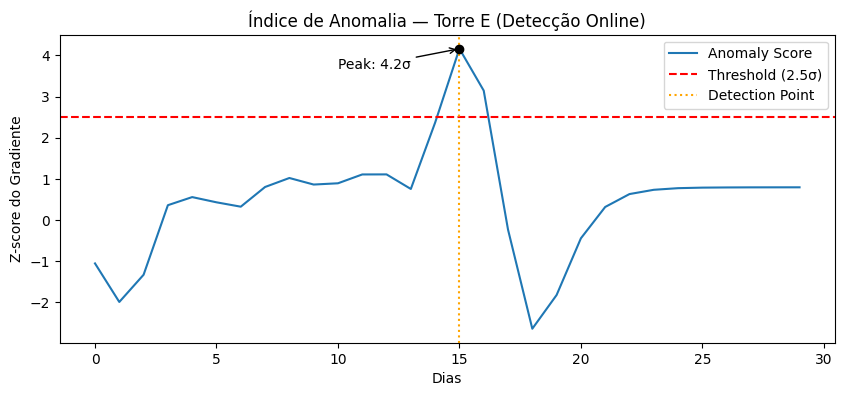

In [255]:
# Visualização baseada em unidades de desvio padrão
plt.figure(figsize=(10,4))
plt.plot(z, label="Anomaly Score")
peak = np.argmax(z)

plt.scatter(peak, z[peak], color='black', zorder=5)

plt.axhline(threshold, color='r', linestyle='--',
            label=f"Threshold ({threshold}σ)")
if detected_day is not None:
    plt.axvline(detected_day, color='orange',
                linestyle=':', label="Detection Point")
peak = np.argmax(z)
plt.annotate(
    f"Peak: {z[peak]:.1f}σ",
    xy=(peak, z[peak]),
    xytext=(peak-5, z[peak]-0.5),
    arrowprops=dict(arrowstyle="->")
)
plt.title("Índice de Anomalia — Torre E (Detecção Online)")
plt.xlabel("Dias")
plt.ylabel("Z-score do Gradiente")
plt.legend()

plt.show()

## Conclusion

### Avaliação de Risco de Vazamento em Torre Similar

A inferência Bayesiana aplicada ao consumo da Torre E, condicionada ao vazamento confirmado na Torre D, resultou em probabilidade posterior global baixa. No entanto, a análise temporal online revelou uma variação abrupta no gradiente das probabilidades ao longo do período monitorado.

Esse comportamento caracteriza uma mudança repentina de regime estatístico, incompatível com flutuações normais sob ruído e consistente com a fase inicial de deterioração observada em sistemas hidráulicos reais.

Embora a evidência acumulada não seja suficiente para confirmar um vazamento, o sinal detectado configura um evento anômalo relevante do ponto de vista operacional, justificando investigação preventiva.

Em ambientes industriais, a detecção precoce de transientes anormais é frequentemente mais valiosa do que a confirmação tardia de falhas, pois permite mitigação antes que o impacto se torne significativo.

**Assim, os resultados indicam:**

- Baixa probabilidade posterior de vazamento estabelecido  
- Presença de indícios de comportamento não estacionário  
- Necessidade de monitoramento contínuo e verificação em campo  

A abordagem demonstra que modelos probabilísticos, quando analisados dinamicamente, podem atuar como sistemas de alerta precoce, mesmo na ausência de evidência conclusiva.